In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from datetime import datetime

# Make charts look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [23]:
BASE_PATH = '/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/'

INSTALLS_PATH = BASE_PATH + 'Installs/'
RATINGS_PATH = BASE_PATH + 'Ratings/'
CRASHES_PATH = BASE_PATH + 'Crashes/'
STORE_PATH = BASE_PATH + 'Store Performance/'

print("Paths set successfully!")

Paths set successfully!


In [25]:
# ── INSTALLS ──────────────────────────────────────────
installs_files = [f for f in os.listdir(INSTALLS_PATH) if f.endswith('.csv')]
installs_df = pd.concat([
    pd.read_csv(INSTALLS_PATH + f, encoding='utf-16', sep=',') for f in installs_files
], ignore_index=True)

# ── RATINGS ───────────────────────────────────────────
ratings_files = [f for f in os.listdir(RATINGS_PATH) if f.endswith('.csv')]
ratings_df = pd.concat([
    pd.read_csv(RATINGS_PATH + f, encoding='utf-16', sep=',') for f in ratings_files
], ignore_index=True)

# ── CRASHES ───────────────────────────────────────────
crashes_files = [f for f in os.listdir(CRASHES_PATH) if f.endswith('.csv')]
crashes_df = pd.concat([
    pd.read_csv(CRASHES_PATH + f, encoding='utf-16', sep=',') for f in crashes_files
], ignore_index=True)

# ── STORE PERFORMANCE ─────────────────────────────────
store_files = [f for f in os.listdir(STORE_PATH) if f.endswith('.csv')]
store_df = pd.concat([
    pd.read_csv(STORE_PATH + f, encoding='utf-16', sep=',') for f in store_files
], ignore_index=True)

print(f"Installs rows: {len(installs_df)}")
print(f"Ratings rows:  {len(ratings_df)}")
print(f"Crashes rows:  {len(crashes_df)}")
print(f"Store rows:    {len(store_df)}")

Installs rows: 197
Ratings rows:  169
Crashes rows:  17
Store rows:    455


In [26]:
# Check installs
print("=== INSTALLS ===")
print(installs_df.dtypes)
print(installs_df.head(3))

print("\n=== RATINGS ===")
print(ratings_df.dtypes)
print(ratings_df.head(3))

print("\n=== CRASHES ===")
print(crashes_df.dtypes)
print(crashes_df.head(3))

print("\n=== STORE ===")
print(store_df.dtypes)
print(store_df.head(3))

=== INSTALLS ===
Date                       object
Package name               object
Daily Device Installs       int64
Daily Device Uninstalls     int64
Daily Device Upgrades       int64
Total User Installs         int64
Daily User Installs         int64
Daily User Uninstalls       int64
Active Device Installs      int64
Install events              int64
Update events               int64
Uninstall events            int64
dtype: object
         Date                Package name  Daily Device Installs  \
0  2025-11-04  com.mechazerogame.lastgame                      2   
1  2025-11-05  com.mechazerogame.lastgame                      0   
2  2025-11-06  com.mechazerogame.lastgame                      0   

   Daily Device Uninstalls  Daily Device Upgrades  Total User Installs  \
0                        0                      0                    0   
1                        0                      0                    0   
2                        0                      0                 

In [27]:
# ── Convert dates and sort ─────────────────────────────

# Installs
installs_df['Date'] = pd.to_datetime(installs_df['Date'])
installs_df = installs_df.sort_values('Date').reset_index(drop=True)

# Ratings
ratings_df['Date'] = pd.to_datetime(ratings_df['Date'])
ratings_df = ratings_df.sort_values('Date').reset_index(drop=True)

# Crashes
crashes_df['Date'] = pd.to_datetime(crashes_df['Date'])
crashes_df = crashes_df.sort_values('Date').reset_index(drop=True)

# Store
store_df['Date'] = pd.to_datetime(store_df['Date'])
store_df = store_df.sort_values('Date').reset_index(drop=True)

# ── Verify ─────────────────────────────────────────────
print("Date types after conversion:")
print(f"  Installs : {installs_df['Date'].dtype}")
print(f"  Ratings  : {ratings_df['Date'].dtype}")
print(f"  Crashes  : {crashes_df['Date'].dtype}")
print(f"  Store    : {store_df['Date'].dtype}")

print("\nDate ranges:")
print(f"  Installs : {installs_df['Date'].min().date()} → {installs_df['Date'].max().date()}")
print(f"  Ratings  : {ratings_df['Date'].min().date()} → {ratings_df['Date'].max().date()}")
print(f"  Crashes  : {crashes_df['Date'].min().date()} → {crashes_df['Date'].max().date()}")
print(f"  Store    : {store_df['Date'].min().date()} → {store_df['Date'].max().date()}")

Date types after conversion:
  Installs : datetime64[ns]
  Ratings  : datetime64[ns]
  Crashes  : datetime64[ns]
  Store    : datetime64[ns]

Date ranges:
  Installs : 2025-11-04 → 2026-05-19
  Ratings  : 2025-11-07 → 2026-04-30
  Crashes  : 2026-03-03 → 2026-04-28
  Store    : 2025-11-04 → 2026-05-06


In [28]:
print("=== INSTALLS SUMMARY ===")
print(installs_df[['Daily Device Installs', 'Daily Device Uninstalls', 'Active Device Installs']].describe())

print("\n=== RATINGS SUMMARY ===")
print(ratings_df[['Daily Average Rating', 'Total Average Rating']].describe())

print("\n=== CRASHES SUMMARY ===")
print(crashes_df[['Daily Crashes', 'Daily ANRs']].describe())

print("\n=== STORE SUMMARY ===")
print(store_df[['Store listing visitors', 'Store listing acquisitions', 'Store listing conversion rate']].describe())

=== INSTALLS SUMMARY ===
       Daily Device Installs  Daily Device Uninstalls  Active Device Installs
count             197.000000                    197.0              197.000000
mean               20.137056                      0.0              298.786802
std                89.478971                      0.0              358.548442
min                 0.000000                      0.0                1.000000
25%                 0.000000                      0.0               29.000000
50%                 0.000000                      0.0               42.000000
75%                 2.000000                      0.0              587.000000
max               591.000000                      0.0             1244.000000

=== RATINGS SUMMARY ===
       Daily Average Rating  Total Average Rating
count            169.000000            169.000000
mean               0.489644              4.097889
std                1.288146              0.794475
min                0.000000              2.66660

What the Summary is Telling Us

Installs:


*   Mean is 20 but median (50%) is 0. That means more than half the days had zero installs. The average is being pulled up entirely by the viral spike days.
*   Max was 591 in a single day — that's the March 3 explosion we saw earlier.


Ratings:


*   Daily Average Rating median is 0 — most days nobody rates the game at all. Ratings are very sparse.
*   Total Average Rating min is 2.67 — that's where the game currently sits at its worst point.


Crashes:


*   Only 17 rows because Google only records days where crashes actually happened. Clean days don't appear.
*   Max 10 crashes in one day — happened during the viral spike.


Store:


*   Max conversion rate 0.333 — meaning 33% of visitors installed during the viral peak. Extremely high.
*   Median conversion is 0 — on most normal days almost nobody converts.

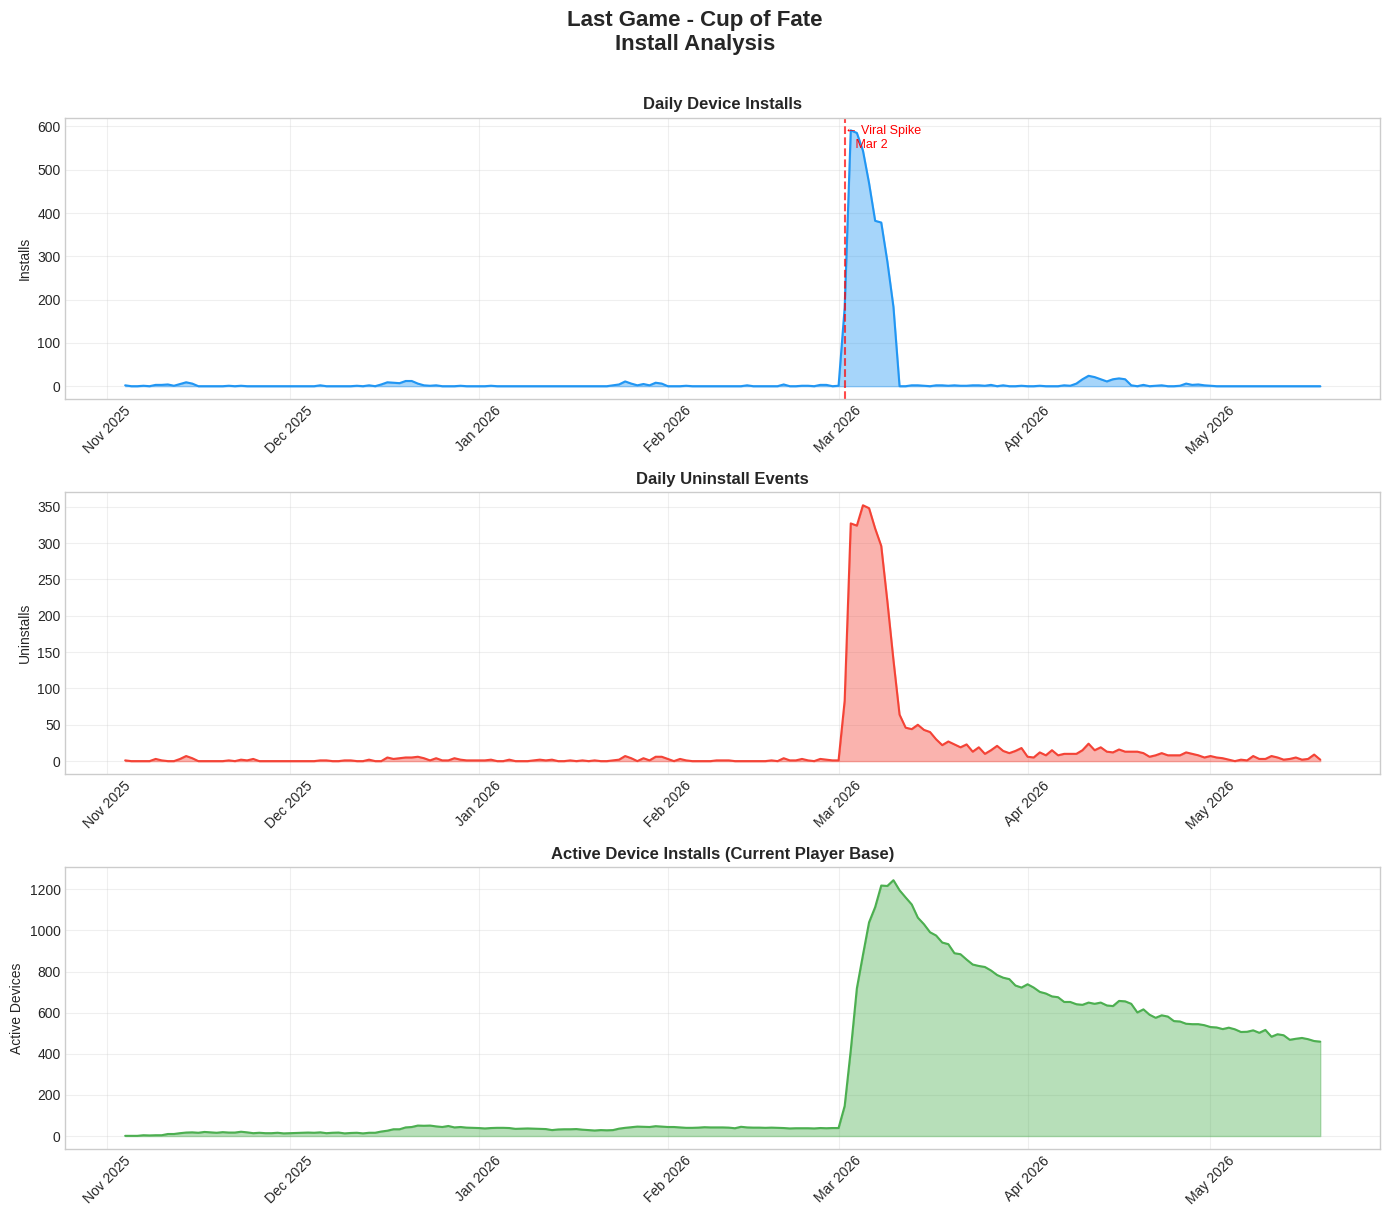

Chart saved!


In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Last Game - Cup of Fate\nInstall Analysis',
             fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Daily Device Installs ──────────────────────
axes[0].fill_between(installs_df['Date'],
                      installs_df['Daily Device Installs'],
                      alpha=0.4, color='#2196F3')
axes[0].plot(installs_df['Date'],
             installs_df['Daily Device Installs'],
             color='#2196F3', linewidth=1.5)
axes[0].set_title('Daily Device Installs', fontweight='bold')
axes[0].set_ylabel('Installs')

# Add annotation for viral spike
axes[0].axvline(pd.Timestamp('2026-03-02'),
                color='red', linestyle='--', alpha=0.7)
axes[0].text(pd.Timestamp('2026-03-02'), 550,
             '← Viral Spike\n   Mar 2',
             color='red', fontsize=9)

# ── Chart 2: Daily Uninstalls ────────────────────────────
axes[1].fill_between(installs_df['Date'],
                      installs_df['Uninstall events'],
                      alpha=0.4, color='#F44336')
axes[1].plot(installs_df['Date'],
             installs_df['Uninstall events'],
             color='#F44336', linewidth=1.5)
axes[1].set_title('Daily Uninstall Events', fontweight='bold')
axes[1].set_ylabel('Uninstalls')

# ── Chart 3: Active Device Installs ─────────────────────
axes[2].fill_between(installs_df['Date'],
                      installs_df['Active Device Installs'],
                      alpha=0.4, color='#4CAF50')
axes[2].plot(installs_df['Date'],
             installs_df['Active Device Installs'],
             color='#4CAF50', linewidth=1.5)
axes[2].set_title('Active Device Installs (Current Player Base)',
                   fontweight='bold')
axes[2].set_ylabel('Active Devices')

# ── Formatting for all charts ────────────────────────────
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/installs_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

What the charts sayinh:

Chart 1:

There was one huge spike in installs during March, but outside of that, almost nothing happened. Imagine a single mountain in the middle of a flat desert.

Chart 2:

Uninstalls followed the same pattern — people downloaded the game during that spike, but most quit soon after.

Chart 3:

Active players peaked at 1,244, but since then the number has been dropping every day. The game is slowly losing players, and new ones aren’t coming in to replace them.

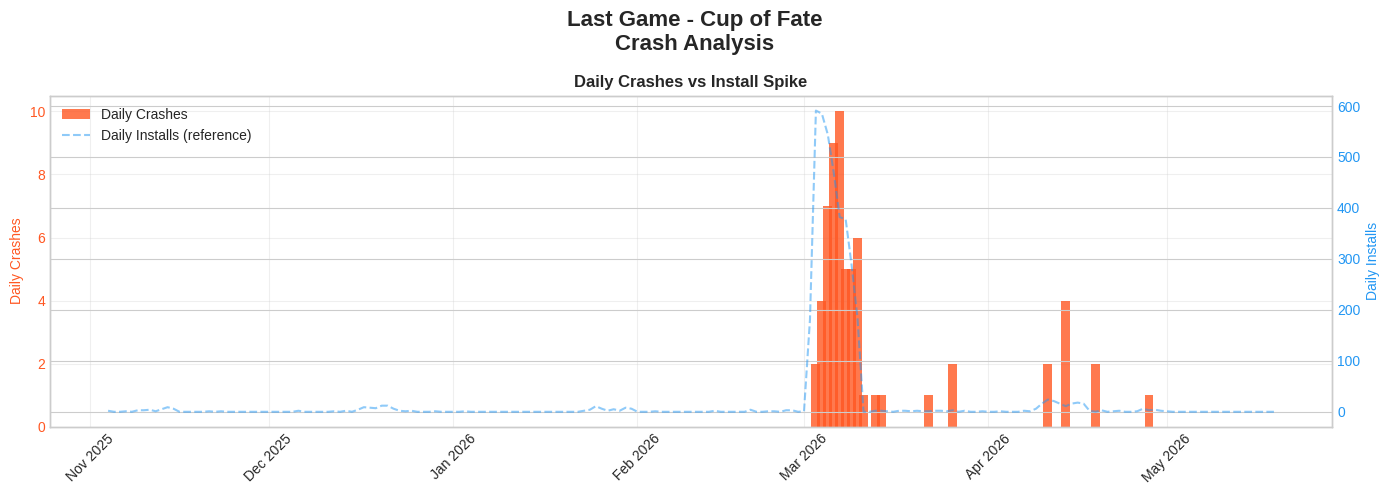

Chart saved!


In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Last Game - Cup of Fate\nCrash Analysis',
             fontsize=16, fontweight='bold')

ax.bar(crashes_df['Date'], crashes_df['Daily Crashes'],
       color='#FF5722', alpha=0.8, width=1.5, label='Daily Crashes')

# Overlay the install spike line for context
ax2 = ax.twinx()
ax2.plot(installs_df['Date'], installs_df['Daily Device Installs'],
         color='#2196F3', linewidth=1.5, alpha=0.5,
         linestyle='--', label='Daily Installs (reference)')
ax2.set_ylabel('Daily Installs', color='#2196F3')
ax2.tick_params(axis='y', labelcolor='#2196F3')

ax.set_title('Daily Crashes vs Install Spike', fontweight='bold')
ax.set_ylabel('Daily Crashes', color='#FF5722')
ax.tick_params(axis='y', labelcolor='#FF5722')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/crashes_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

What the Crash Chart is Telling Us

1. Crashes only appeared because of the viral spike
Before March, installs were near zero so crashes never really showed up. The bugs were always there — just never triggered enough times to register. The moment hundreds of people downloaded the game, those hidden bugs got exposed all at once.

2. The timing was the worst possible
Crashes peaked at 10 per day right in the middle of the install wave. These weren't existing players — these were brand new users experiencing the game for the very first time. First impressions on mobile are everything.

3. Your theory is correct
Download → crash → uninstall. The data backs it up. Installs spiked first, crashes followed within 1–2 days, uninstalls followed crashes. The sequence is too clean to be a coincidence.

4. The April crashes are a separate concern
Small cluster of crashes in April even though installs had already dropped back to near zero. This means the bugs were never fully fixed after March. Existing players are still hitting them.

5. Small numbers, big damage
10 crashes sounds minor. But each crash happening to a brand new curious player almost always ends the same way — uninstall and a bad rating. The damage was disproportionate to the number.


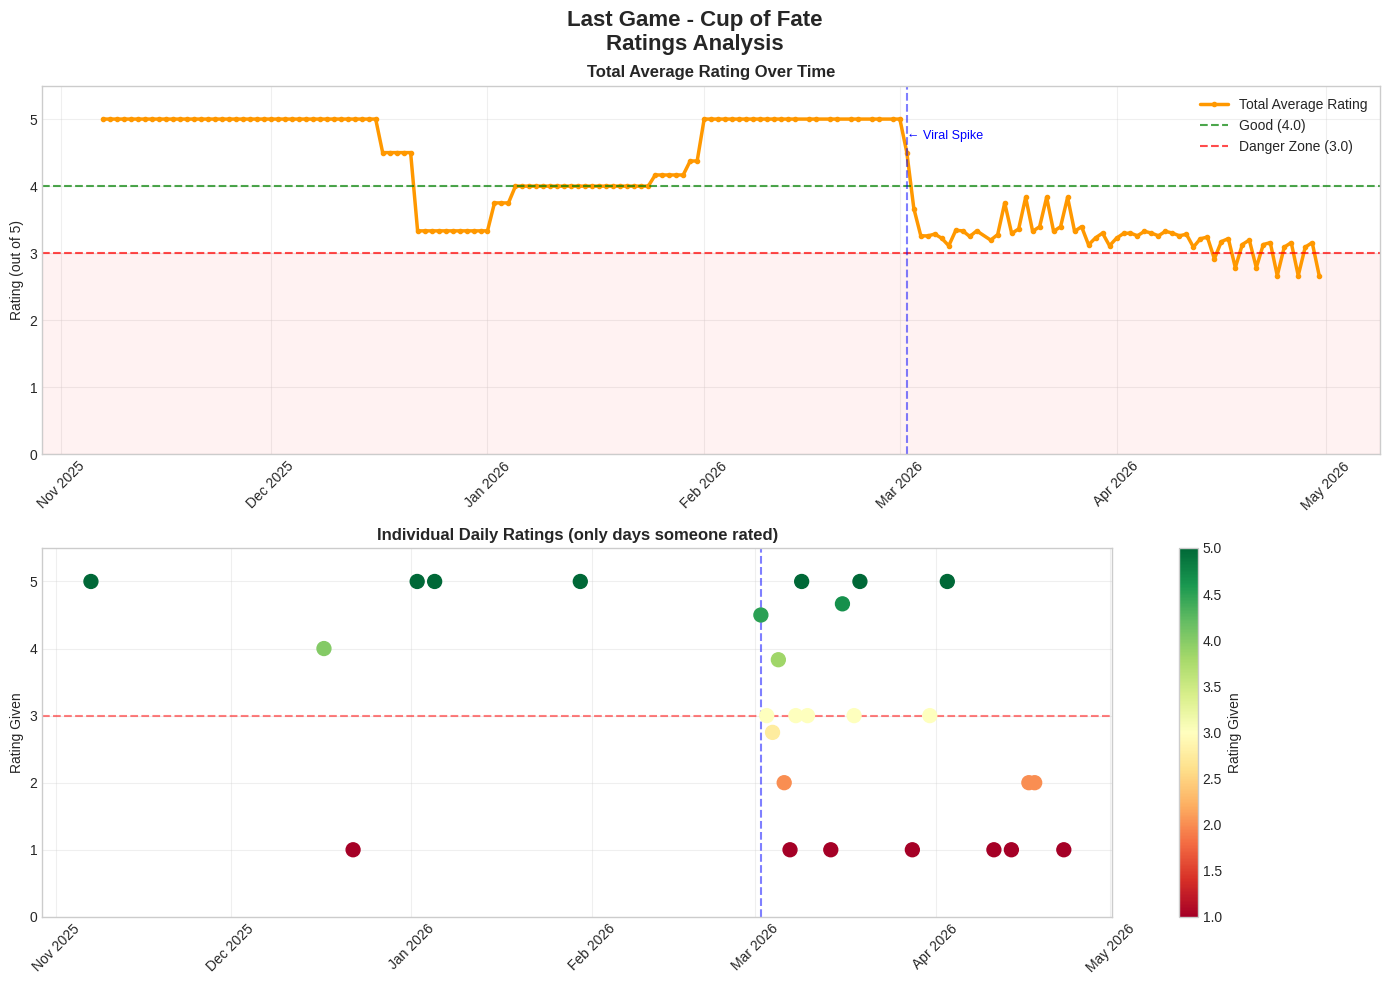

Chart saved!


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Last Game - Cup of Fate\nRatings Analysis',
             fontsize=16, fontweight='bold')

# ── Chart 1: Total Average Rating over time ──────────────
axes[0].plot(ratings_df['Date'], ratings_df['Total Average Rating'],
             color='#FF9800', linewidth=2.5, marker='o',
             markersize=3, label='Total Average Rating')

# Add threshold lines
axes[0].axhline(y=4.0, color='green', linestyle='--',
                alpha=0.7, label='Good (4.0)')
axes[0].axhline(y=3.0, color='red', linestyle='--',
                alpha=0.7, label='Danger Zone (3.0)')

# Shade danger zone
axes[0].axhspan(0, 3.0, alpha=0.05, color='red')

# Mark viral spike
axes[0].axvline(pd.Timestamp('2026-03-02'),
                color='blue', linestyle='--', alpha=0.5)
axes[0].text(pd.Timestamp('2026-03-02'), 4.7,
             '← Viral Spike', color='blue', fontsize=9)

axes[0].set_title('Total Average Rating Over Time', fontweight='bold')
axes[0].set_ylabel('Rating (out of 5)')
axes[0].set_ylim(0, 5.5)
axes[0].legend()

# ── Chart 2: Daily ratings received ──────────────────────
# Filter only days where someone actually rated
rated_days = ratings_df[ratings_df['Daily Average Rating'] > 0]

scatter = axes[1].scatter(rated_days['Date'],
                           rated_days['Daily Average Rating'],
                           c=rated_days['Daily Average Rating'],
                           cmap='RdYlGn', vmin=1, vmax=5,
                           s=100, zorder=3)

axes[1].axhline(y=3.0, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(pd.Timestamp('2026-03-02'),
                color='blue', linestyle='--', alpha=0.5)

plt.colorbar(scatter, ax=axes[1], label='Rating Given')
axes[1].set_title('Individual Daily Ratings (only days someone rated)',
                   fontweight='bold')
axes[1].set_ylabel('Rating Given')
axes[1].set_ylim(0, 5.5)

# ── Formatting ────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/ratings_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

What the Ratings Chart is Telling Us

1. The game started with a perfect reputation
November to February — sitting at 5.0 stars. Only a handful of people rated it, mostly friends or early supporters. Small but clean.
2. December had the first warning sign
You can see the orange line dip around December — that 1-star rating we identified earlier dropped the total from 5.0 to 3.3. With so few ratings at the time, one unhappy person had massive influence.
3. February reset brought it back to 5.0
The rating climbed back to perfect just before the viral spike. So when the viral wave hit, the game was showing 5 stars on the store listing. People saw a 5-star game and felt confident downloading it.
4. The viral spike destroyed the rating instantly
Look at the top chart — the moment the blue dashed line appears (March 2), the orange line drops off a cliff. Within one week it fell from 5.0 all the way to around 3.1. That's the fastest and most damaging drop in the entire timeline.
5. The bottom chart tells you exactly who was unhappy
After March 2 you can see a flood of red and dark red dots at 1.0 and 2.0. Before March there were almost only green dots at 5.0. The viral audience was a completely different type of user — harsher, less patient, more likely to rate negatively after a bad experience.
6. The rating is now dangerously close to the red zone
The top chart shows the line hovering just above 3.0 and actually dipping below it toward April-May. That red dashed line is the danger zone. Below 3.0 on Google Play is where the algorithm starts hiding your game from search results. Your friend is right on the edge.


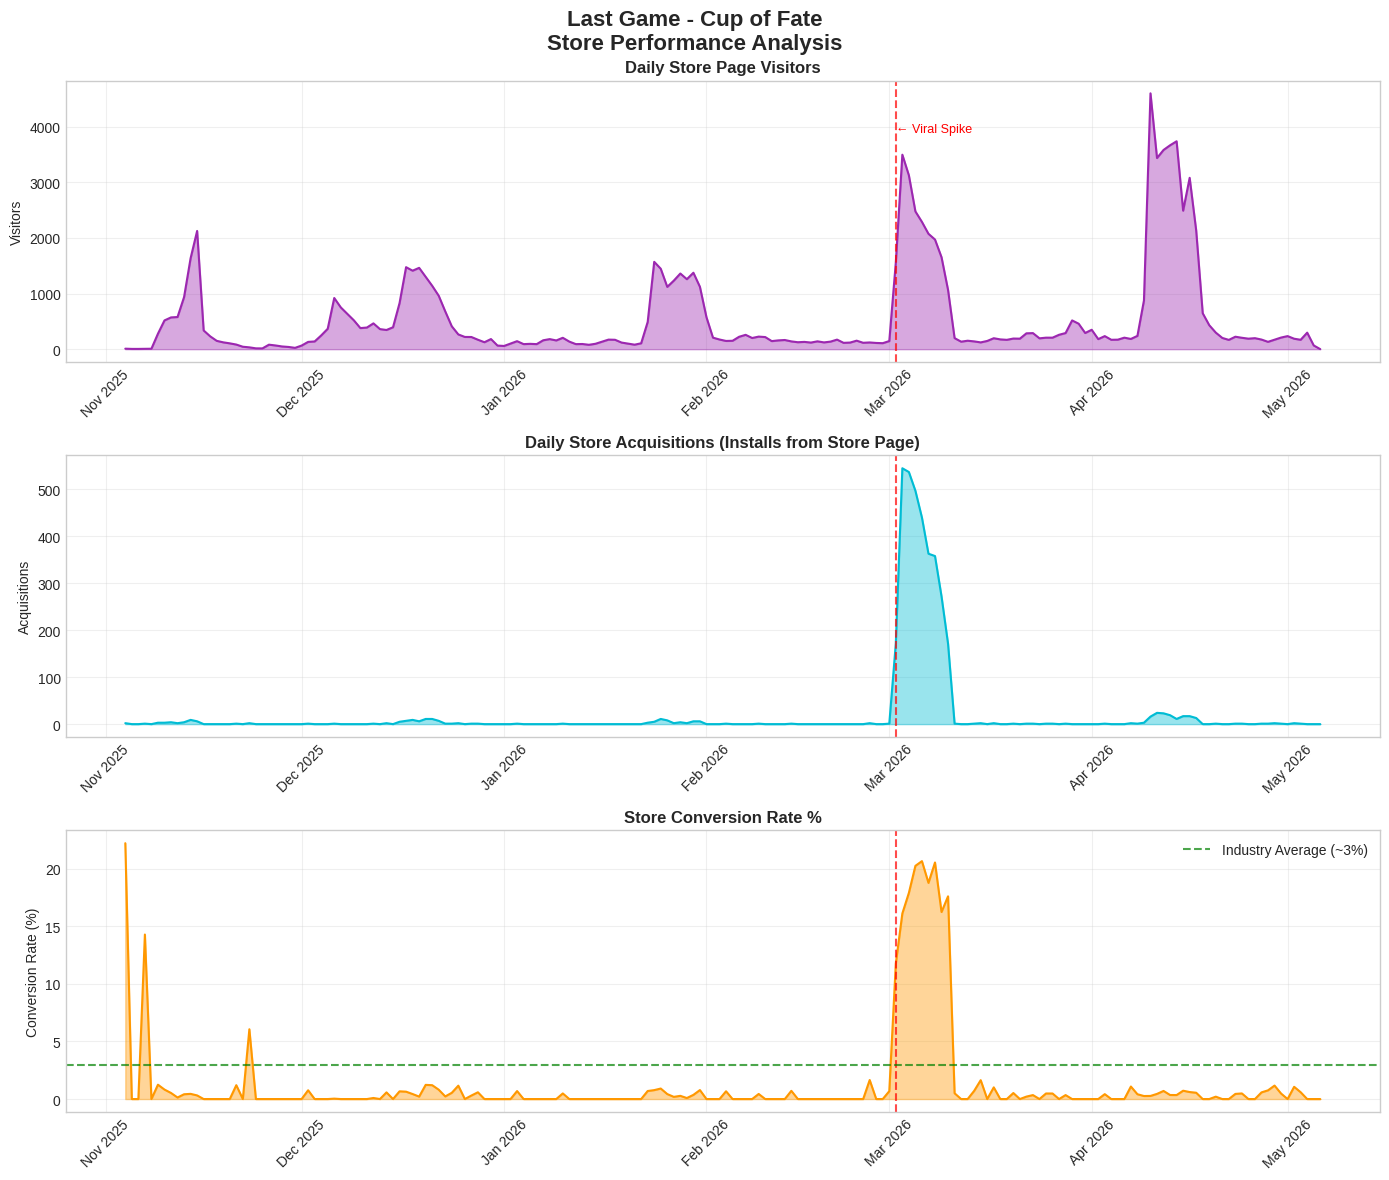

Chart saved!


In [32]:
# ── Aggregate store data by date (sum across all countries) ──
store_daily = store_df.groupby('Date').agg({
    'Store listing visitors': 'sum',
    'Store listing acquisitions': 'sum',
    'Store listing conversion rate': 'mean'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Last Game - Cup of Fate\nStore Performance Analysis',
             fontsize=16, fontweight='bold')

# ── Chart 1: Daily Store Visitors ────────────────────────
axes[0].fill_between(store_daily['Date'],
                      store_daily['Store listing visitors'],
                      alpha=0.4, color='#9C27B0')
axes[0].plot(store_daily['Date'],
             store_daily['Store listing visitors'],
             color='#9C27B0', linewidth=1.5)
axes[0].axvline(pd.Timestamp('2026-03-02'),
                color='red', linestyle='--', alpha=0.7)
axes[0].text(pd.Timestamp('2026-03-02'),
             store_daily['Store listing visitors'].max() * 0.85,
             '← Viral Spike', color='red', fontsize=9)
axes[0].set_title('Daily Store Page Visitors', fontweight='bold')
axes[0].set_ylabel('Visitors')

# ── Chart 2: Daily Acquisitions ──────────────────────────
axes[1].fill_between(store_daily['Date'],
                      store_daily['Store listing acquisitions'],
                      alpha=0.4, color='#00BCD4')
axes[1].plot(store_daily['Date'],
             store_daily['Store listing acquisitions'],
             color='#00BCD4', linewidth=1.5)
axes[1].axvline(pd.Timestamp('2026-03-02'),
                color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Daily Store Acquisitions (Installs from Store Page)',
                   fontweight='bold')
axes[1].set_ylabel('Acquisitions')

# ── Chart 3: Conversion Rate ─────────────────────────────
axes[2].fill_between(store_daily['Date'],
                      store_daily['Store listing conversion rate'] * 100,
                      alpha=0.4, color='#FF9800')
axes[2].plot(store_daily['Date'],
             store_daily['Store listing conversion rate'] * 100,
             color='#FF9800', linewidth=1.5)
axes[2].axvline(pd.Timestamp('2026-03-02'),
                color='red', linestyle='--', alpha=0.7)
axes[2].axhline(y=3, color='green', linestyle='--',
                alpha=0.7, label='Industry Average (~3%)')
axes[2].set_title('Store Conversion Rate %', fontweight='bold')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].legend()

# ── Formatting ────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/store_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

What the Store Performance Chart is Telling Us

1. People were finding the store page long before March
Look at the top chart — there were visitor spikes in November, December, and January too. Hundreds to over a thousand visitors per day. But look at the middle chart during those same periods — acquisitions are basically flat zero. People were visiting but not installing at all.
2. March was different because visitors came with intention
During the viral spike, visitors AND acquisitions spiked together. The conversion rate hit 20%+ meaning 1 in 5 people who visited the store page installed immediately. Compare that to November where thousands visited and almost nobody installed. The difference is intent — March visitors already wanted the game before they even opened the store page.
3. April tells the most important story
Look at the top chart in April — store visitors actually spiked HIGHER than March in some days, reaching 4,000+. But look at the middle chart — acquisitions stayed almost completely flat. And the bottom chart — conversion rate stayed below the green industry average line the whole time.
This is the rating effect in action. Thousands of people visited the store page in April, saw a 3-star rating, and decided not to install. The store page traffic was there — the rating killed the conversion.
4. The early November spikes are mysterious
Those early visitor spikes before the game had any real traction are interesting. Someone was driving traffic to the store page — possibly your friend sharing it himself, or an early post somewhere. But the game wasn't ready to convert them.

Simple Conclusion:

The store page is getting traffic consistently. The problem is no longer discovery — people are finding the game. The problem is the 3-star rating is actively blocking conversions. Fix the rating, and the existing traffic could start converting again.

/tmp/ipykernel_3700/1460853488.py:91: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3700/1460853488.py:91: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3700/1460853488.py:91: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3700/1460853488.py:91: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3700/1460853488.py:92: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/complete_overview.png',
/tmp/ipykernel_3700/1460853488.py:92: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('/content/drive/MyDrive/MechaZeroGame Google P

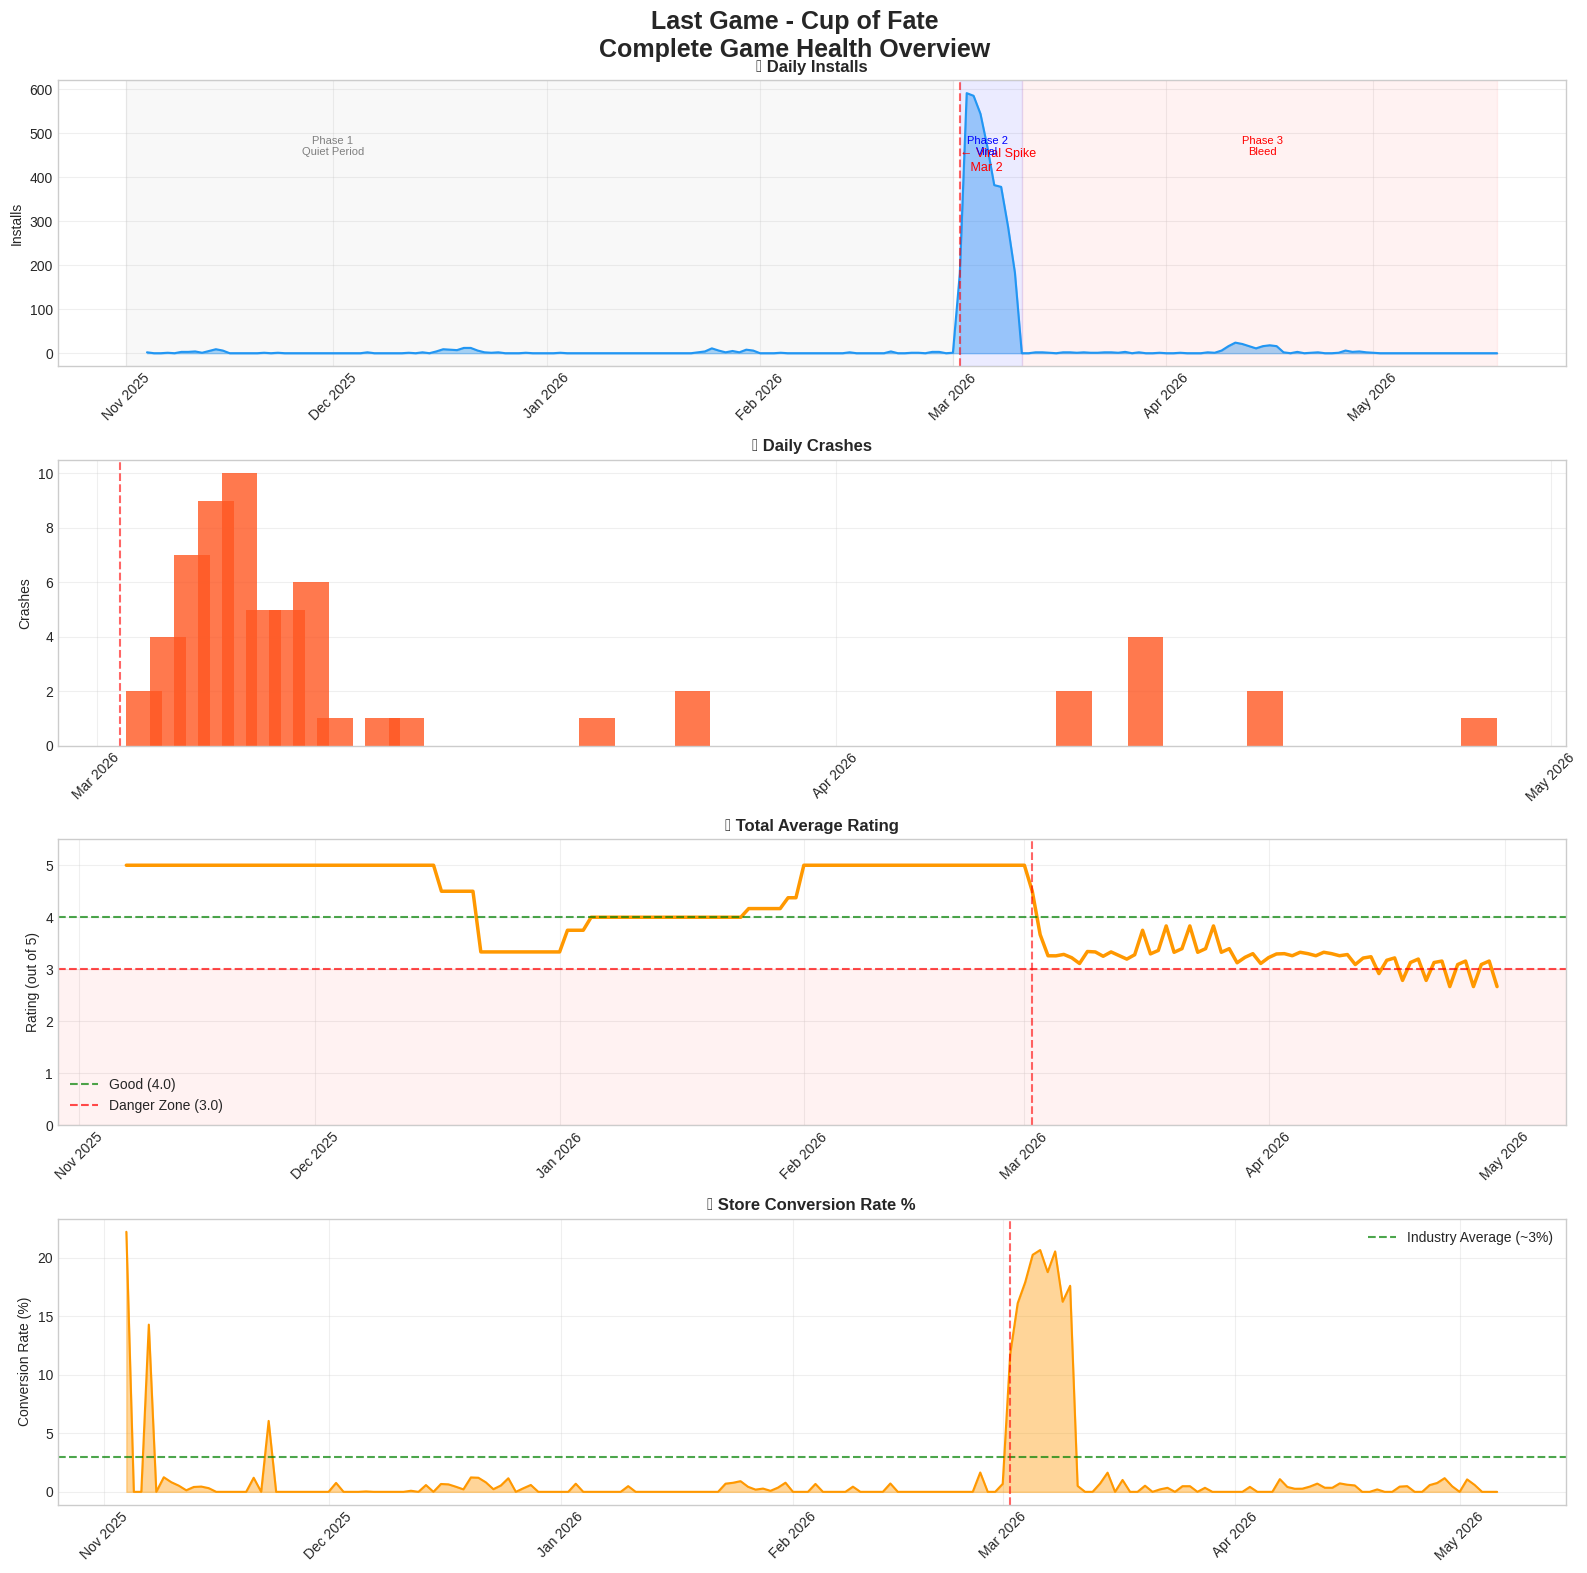

Chart saved!


In [33]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Last Game - Cup of Fate\nComplete Game Health Overview',
             fontsize=18, fontweight='bold')

# ── Shared viral spike line for all charts ───────────────
viral_date = pd.Timestamp('2026-03-02')

# ── Chart 1: Daily Installs ──────────────────────────────
axes[0].fill_between(installs_df['Date'],
                      installs_df['Daily Device Installs'],
                      alpha=0.4, color='#2196F3')
axes[0].plot(installs_df['Date'],
             installs_df['Daily Device Installs'],
             color='#2196F3', linewidth=1.5)
axes[0].set_title('① Daily Installs', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Installs')

# ── Chart 2: Crashes ─────────────────────────────────────
axes[1].bar(crashes_df['Date'], crashes_df['Daily Crashes'],
            color='#FF5722', alpha=0.8, width=1.5)
axes[1].set_title('② Daily Crashes', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Crashes')

# ── Chart 3: Total Average Rating ───────────────────────
axes[2].plot(ratings_df['Date'],
             ratings_df['Total Average Rating'],
             color='#FF9800', linewidth=2.5)
axes[2].axhline(y=4.0, color='green', linestyle='--',
                alpha=0.7, label='Good (4.0)')
axes[2].axhline(y=3.0, color='red', linestyle='--',
                alpha=0.7, label='Danger Zone (3.0)')
axes[2].axhspan(0, 3.0, alpha=0.05, color='red')
axes[2].set_title('③ Total Average Rating', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Rating (out of 5)')
axes[2].set_ylim(0, 5.5)
axes[2].legend(loc='lower left')

# ── Chart 4: Store Conversion Rate ──────────────────────
axes[3].fill_between(store_daily['Date'],
                      store_daily['Store listing conversion rate'] * 100,
                      alpha=0.4, color='#FF9800')
axes[3].plot(store_daily['Date'],
             store_daily['Store listing conversion rate'] * 100,
             color='#FF9800', linewidth=1.5)
axes[3].axhline(y=3, color='green', linestyle='--',
                alpha=0.7, label='Industry Average (~3%)')
axes[3].set_title('④ Store Conversion Rate %', fontweight='bold', fontsize=12)
axes[3].set_ylabel('Conversion Rate (%)')
axes[3].legend(loc='upper right')

# ── Add viral spike line + annotations to all charts ────
labels = ['Viral\nSpike', '', '', '']
for i, ax in enumerate(axes):
    ax.axvline(viral_date, color='red',
               linestyle='--', alpha=0.6, linewidth=1.5)
    if i == 0:
        ax.text(viral_date,
                installs_df['Daily Device Installs'].max() * 0.7,
                '← Viral Spike\n   Mar 2',
                color='red', fontsize=9)

# ── Add phase labels on Chart 1 ─────────────────────────
axes[0].axvspan(pd.Timestamp('2025-11-01'),
                pd.Timestamp('2026-03-01'),
                alpha=0.05, color='gray')
axes[0].text(pd.Timestamp('2025-12-01'), 450,
             'Phase 1\nQuiet Period',
             color='gray', fontsize=8, ha='center')

axes[0].axvspan(pd.Timestamp('2026-03-02'),
                pd.Timestamp('2026-03-11'),
                alpha=0.08, color='blue')
axes[0].text(pd.Timestamp('2026-03-06'), 450,
             'Phase 2\nViral',
             color='blue', fontsize=8, ha='center')

axes[0].axvspan(pd.Timestamp('2026-03-11'),
                pd.Timestamp('2026-05-19'),
                alpha=0.05, color='red')
axes[0].text(pd.Timestamp('2026-04-15'), 450,
             'Phase 3\nBleed',
             color='red', fontsize=8, ha='center')

# ── Formatting ────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/complete_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Now we have all 5 charts done:

✅ Install Analysis

✅ Crash Analysis

✅ Ratings Analysis

✅ Store Performance Analysis

✅ Complete Overview

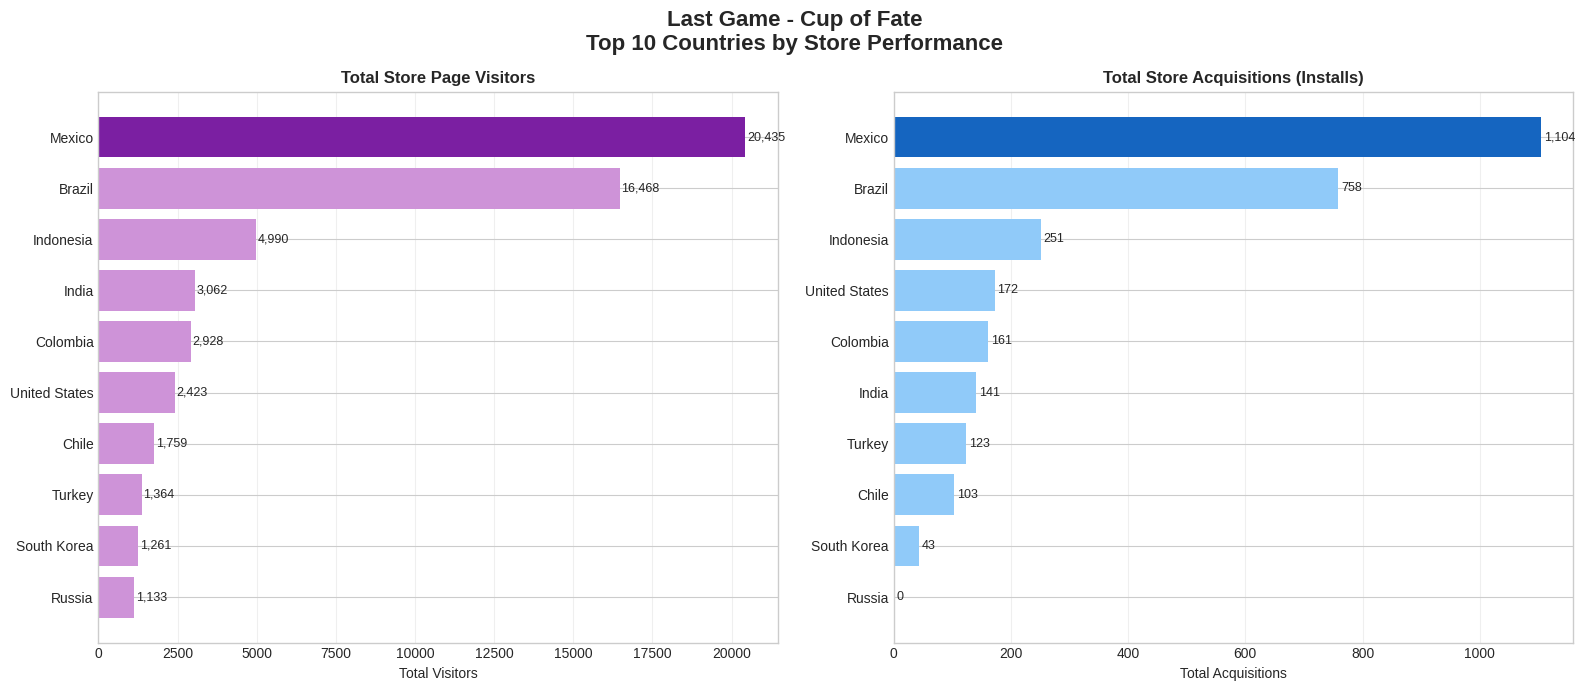

Chart saved!


In [34]:
# ── Aggregate total visitors and acquisitions by country ──
country_df = store_df.groupby('Country / region').agg({
    'Store listing visitors': 'sum',
    'Store listing acquisitions': 'sum'
}).reset_index()

# Remove 'Other' and 'ZZ' for cleaner chart
country_df = country_df[
    ~country_df['Country / region'].isin(['Other', 'ZZ'])
]

# Sort by visitors
country_df = country_df.sort_values(
    'Store listing visitors', ascending=False
).head(10)

# Country code to full name mapping
country_names = {
    'BR': 'Brazil', 'MX': 'Mexico', 'ID': 'Indonesia',
    'IN': 'India', 'US': 'United States', 'RU': 'Russia',
    'TR': 'Turkey', 'KR': 'South Korea', 'PL': 'Poland',
    'CO': 'Colombia', 'CL': 'Chile', 'DE': 'Germany',
    'TW': 'Taiwan', 'BD': 'Bangladesh', 'PE': 'Peru',
    'EC': 'Ecuador', 'DZ': 'Algeria', 'EG': 'Egypt',
    'IQ': 'Iraq', 'MA': 'Morocco'
}
country_df['Country'] = country_df['Country / region'].map(
    country_names
).fillna(country_df['Country / region'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Last Game - Cup of Fate\nTop 10 Countries by Store Performance',
             fontsize=16, fontweight='bold')

# ── Chart 1: Visitors by Country ─────────────────────────
colors_visitors = ['#7B1FA2' if i == 0 else '#CE93D8'
                   for i in range(len(country_df))]
bars1 = axes[0].barh(country_df['Country'],
                      country_df['Store listing visitors'],
                      color=colors_visitors)
axes[0].set_title('Total Store Page Visitors', fontweight='bold')
axes[0].set_xlabel('Total Visitors')
axes[0].invert_yaxis()

# Add value labels
for bar, val in zip(bars1, country_df['Store listing visitors']):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# ── Chart 2: Acquisitions by Country ─────────────────────
country_acq = country_df.sort_values(
    'Store listing acquisitions', ascending=False
)
colors_acq = ['#1565C0' if i == 0 else '#90CAF9'
               for i in range(len(country_acq))]
bars2 = axes[1].barh(country_acq['Country'],
                      country_acq['Store listing acquisitions'],
                      color=colors_acq)
axes[1].set_title('Total Store Acquisitions (Installs)', fontweight='bold')
axes[1].set_xlabel('Total Acquisitions')
axes[1].invert_yaxis()

# Add value labels
for bar, val in zip(bars2, country_acq['Store listing acquisitions']):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MechaZeroGame Google Play Statistics/Last Game/country_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

This game has a natural audience — Latin America. If he wants to grow, that's where to focus. Localizing the store listing properly in Spanish and Portuguese, and trying to reach creators in that region again, would be the highest leverage move.

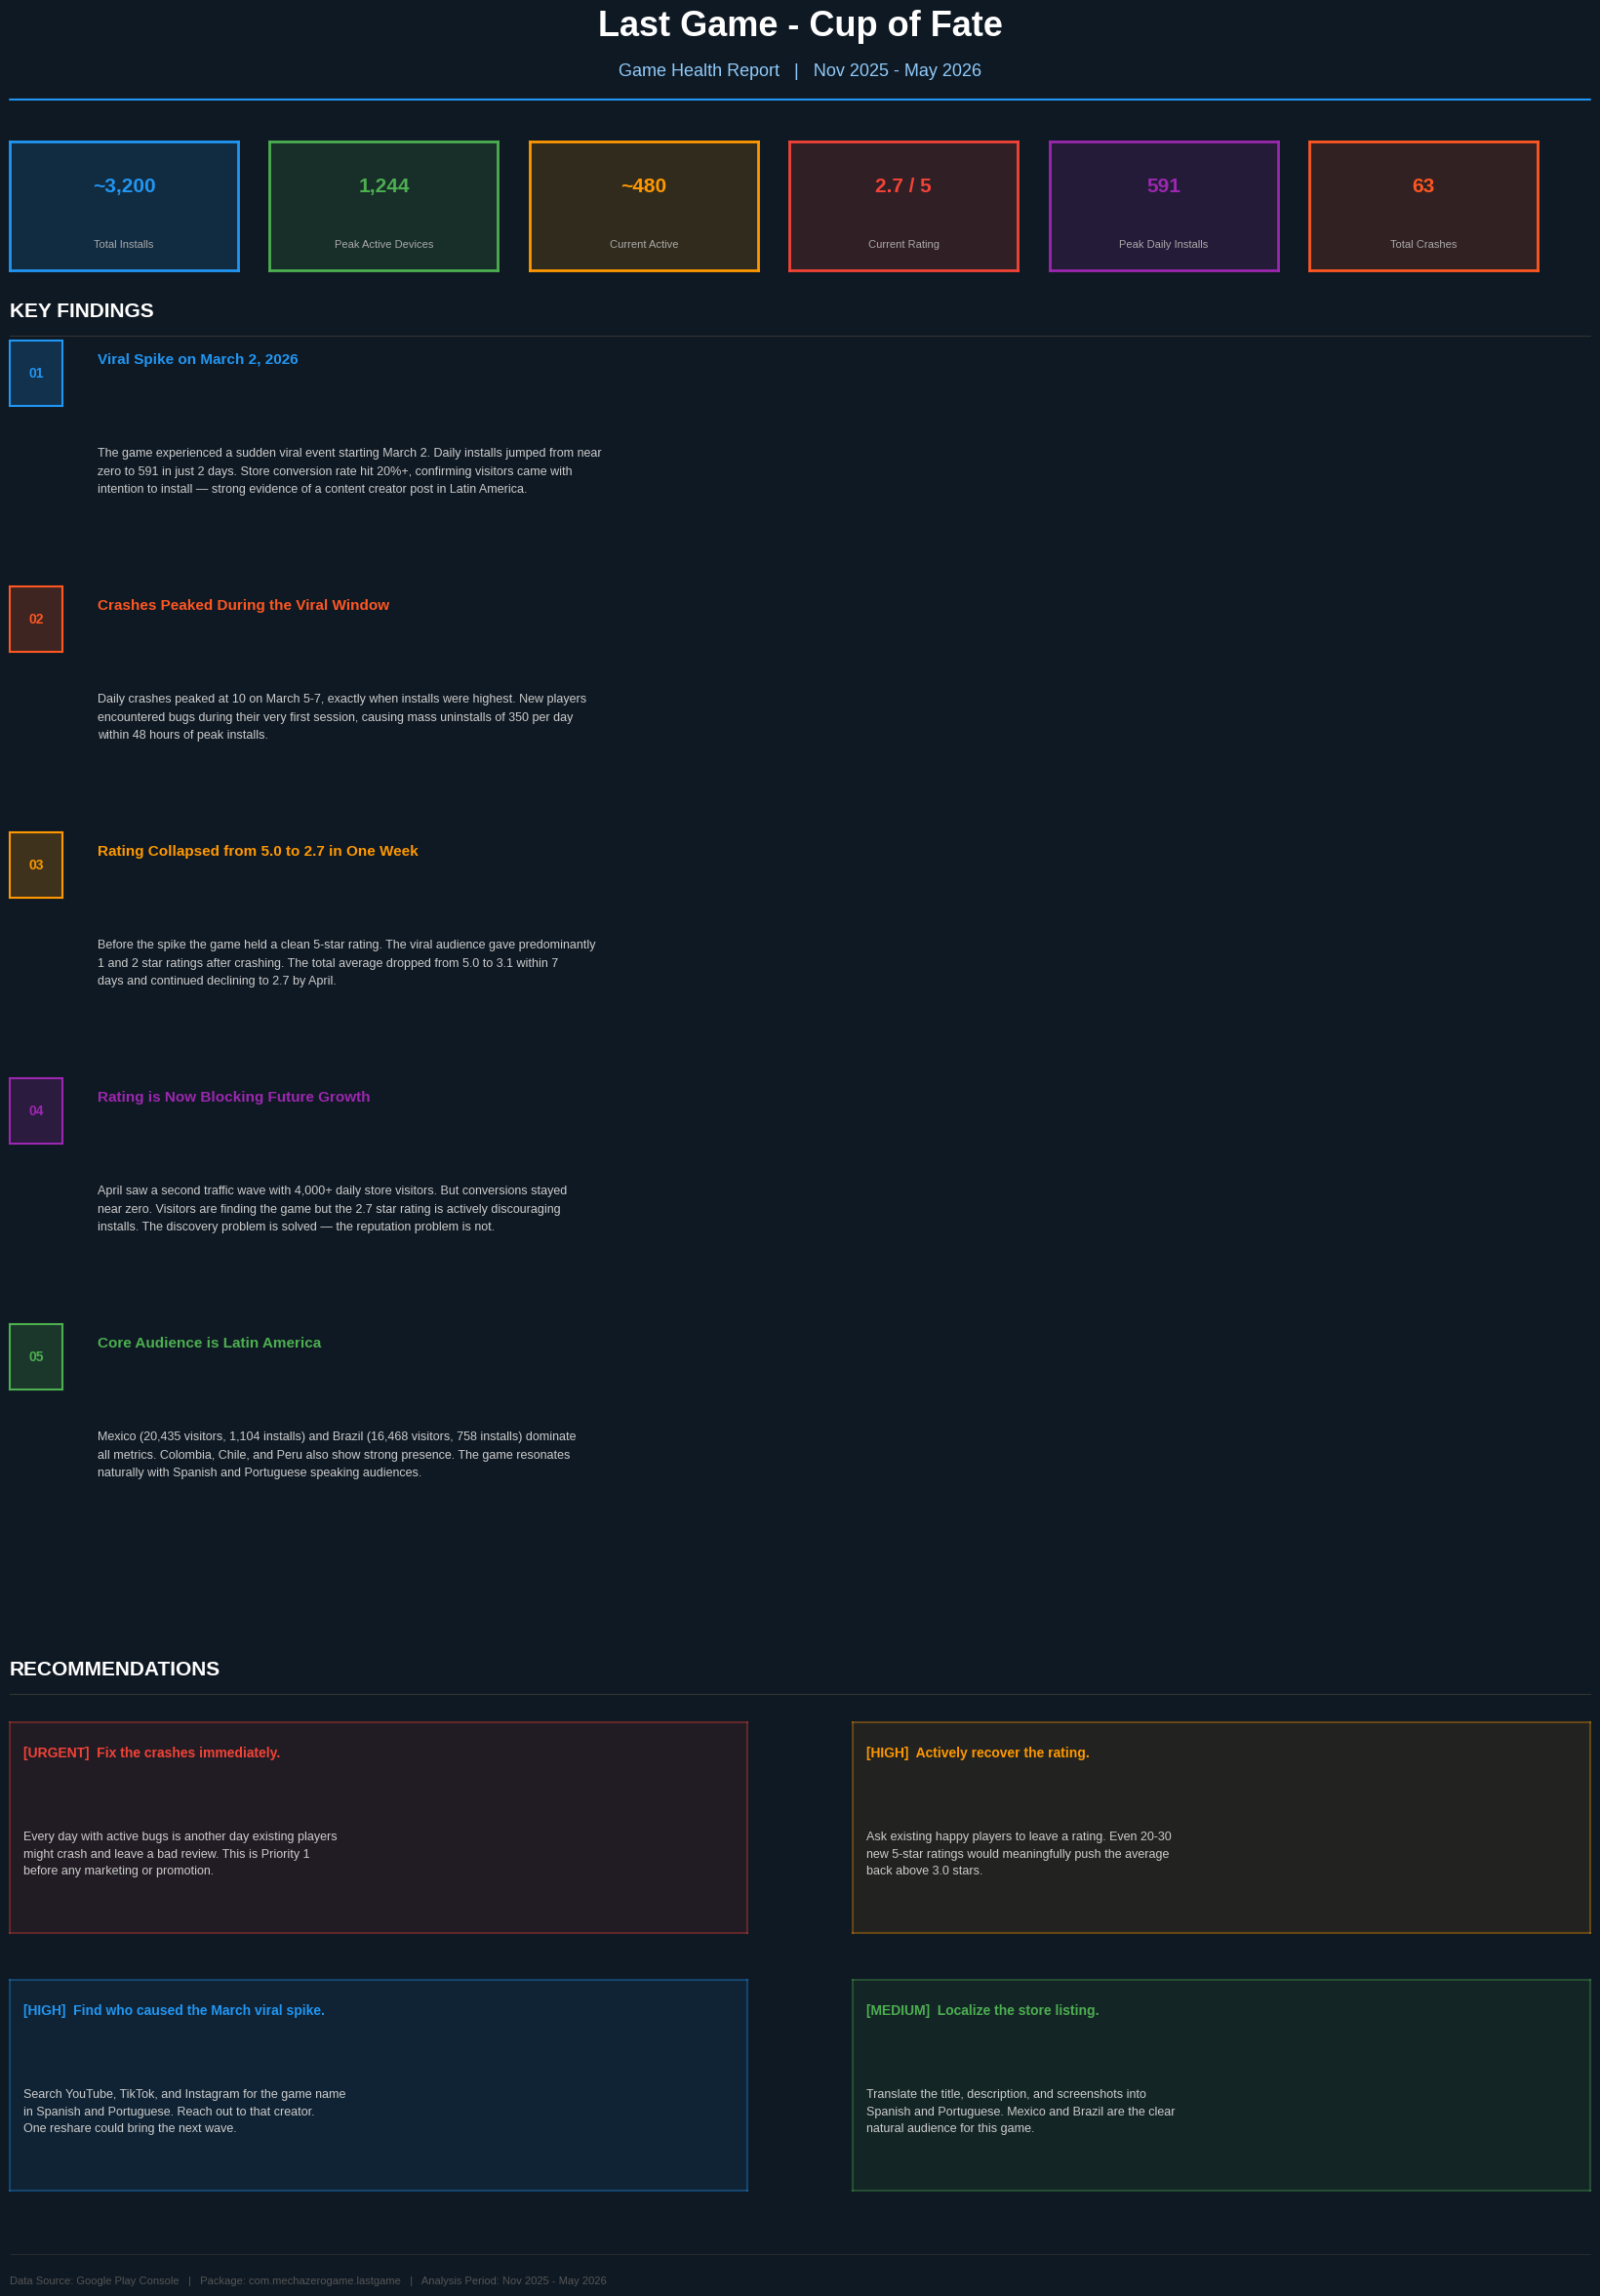

Summary report saved!


In [36]:
fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor('#0F1923')

# ── Title ─────────────────────────────────────────────────
fig.text(0.5, 0.975, 'Last Game - Cup of Fate',
         ha='center', fontsize=26, fontweight='bold', color='white')
fig.text(0.5, 0.958, 'Game Health Report   |   Nov 2025 - May 2026',
         ha='center', fontsize=13, color='#90CAF9')

fig.add_artist(plt.Line2D([0.05, 0.95], [0.948, 0.948],
               color='#2196F3', linewidth=1.5,
               transform=fig.transFigure))

# ── KPI Boxes ─────────────────────────────────────────────
kpis = [
    ('Total Installs',      '~3,200', '#2196F3'),
    ('Peak Active Devices', '1,244',  '#4CAF50'),
    ('Current Active',      '~480',   '#FF9800'),
    ('Current Rating',      '2.7 / 5','#F44336'),
    ('Peak Daily Installs', '591',    '#9C27B0'),
    ('Total Crashes',       '63',     '#FF5722'),
]

box_w = 0.13
box_h = 0.055
gap = 0.018
start_x = 0.05
kpi_y = 0.875

for i, (label, value, color) in enumerate(kpis):
    x = start_x + i * (box_w + gap)
    ax_k = fig.add_axes([x, kpi_y, box_w, box_h])
    ax_k.set_facecolor(color + '25')
    ax_k.set_xlim(0, 1)
    ax_k.set_ylim(0, 1)
    for sp in ax_k.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(2)
    ax_k.set_xticks([])
    ax_k.set_yticks([])
    ax_k.text(0.5, 0.65, value, ha='center', va='center',
              fontsize=15, fontweight='bold', color=color,
              transform=ax_k.transAxes)
    ax_k.text(0.5, 0.2, label, ha='center', va='center',
              fontsize=8, color='#AAAAAA',
              transform=ax_k.transAxes)

# ── KEY FINDINGS header ───────────────────────────────────
fig.text(0.05, 0.855, 'KEY FINDINGS',
         fontsize=15, fontweight='bold', color='white')
fig.add_artist(plt.Line2D([0.05, 0.95], [0.847, 0.847],
               color='#333333', linewidth=0.8,
               transform=fig.transFigure))

findings = [
    ('#2196F3', '01', 'Viral Spike on March 2, 2026',
     'The game experienced a sudden viral event starting March 2. Daily installs jumped from near\n'
     'zero to 591 in just 2 days. Store conversion rate hit 20%+, confirming visitors came with\n'
     'intention to install — strong evidence of a content creator post in Latin America.'),

    ('#FF5722', '02', 'Crashes Peaked During the Viral Window',
     'Daily crashes peaked at 10 on March 5-7, exactly when installs were highest. New players\n'
     'encountered bugs during their very first session, causing mass uninstalls of 350 per day\n'
     'within 48 hours of peak installs.'),

    ('#FF9800', '03', 'Rating Collapsed from 5.0 to 2.7 in One Week',
     'Before the spike the game held a clean 5-star rating. The viral audience gave predominantly\n'
     '1 and 2 star ratings after crashing. The total average dropped from 5.0 to 3.1 within 7\n'
     'days and continued declining to 2.7 by April.'),

    ('#9C27B0', '04', 'Rating is Now Blocking Future Growth',
     'April saw a second traffic wave with 4,000+ daily store visitors. But conversions stayed\n'
     'near zero. Visitors are finding the game but the 2.7 star rating is actively discouraging\n'
     'installs. The discovery problem is solved — the reputation problem is not.'),

    ('#4CAF50', '05', 'Core Audience is Latin America',
     'Mexico (20,435 visitors, 1,104 installs) and Brazil (16,468 visitors, 758 installs) dominate\n'
     'all metrics. Colombia, Chile, and Peru also show strong presence. The game resonates\n'
     'naturally with Spanish and Portuguese speaking audiences.'),
]

y_f = 0.835
for color, num, title, body in findings:
    # Number badge
    ax_num = fig.add_axes([0.05, y_f - 0.018, 0.03, 0.028])
    ax_num.set_facecolor(color + '33')
    ax_num.set_xlim(0, 1)
    ax_num.set_ylim(0, 1)
    for sp in ax_num.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(1.5)
    ax_num.set_xticks([])
    ax_num.set_yticks([])
    ax_num.text(0.5, 0.5, num, ha='center', va='center',
                fontsize=10, fontweight='bold', color=color,
                transform=ax_num.transAxes)

    fig.text(0.10, y_f, title,
             fontsize=11, fontweight='bold', color=color)
    fig.text(0.10, y_f - 0.055, body,
             fontsize=9, color='#CCCCCC', linespacing=1.7)
    y_f -= 0.105

# ── RECOMMENDATIONS header ────────────────────────────────
fig.text(0.05, 0.275, 'RECOMMENDATIONS',
         fontsize=15, fontweight='bold', color='white')
fig.add_artist(plt.Line2D([0.05, 0.95], [0.267, 0.267],
               color='#333333', linewidth=0.8,
               transform=fig.transFigure))

recs = [
    ('#F44336', 'URGENT', 'Fix the crashes immediately.',
     'Every day with active bugs is another day existing players\n'
     'might crash and leave a bad review. This is Priority 1\n'
     'before any marketing or promotion.'),

    ('#FF9800', 'HIGH', 'Actively recover the rating.',
     'Ask existing happy players to leave a rating. Even 20-30\n'
     'new 5-star ratings would meaningfully push the average\n'
     'back above 3.0 stars.'),

    ('#2196F3', 'HIGH', 'Find who caused the March viral spike.',
     'Search YouTube, TikTok, and Instagram for the game name\n'
     'in Spanish and Portuguese. Reach out to that creator.\n'
     'One reshare could bring the next wave.'),

    ('#4CAF50', 'MEDIUM', 'Localize the store listing.',
     'Translate the title, description, and screenshots into\n'
     'Spanish and Portuguese. Mexico and Brazil are the clear\n'
     'natural audience for this game.'),
]

rec_w = 0.42
rec_h = 0.09
positions = [
    (0.05, 0.245), (0.53, 0.245),
    (0.05, 0.135), (0.53, 0.135),
]

for (x, y), (color, urgency, title, body) in zip(positions, recs):
    ax_r = fig.add_axes([x, y - rec_h + 0.01, rec_w, rec_h])
    ax_r.set_facecolor(color + '15')
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(0, 1)
    for sp in ax_r.spines.values():
        sp.set_edgecolor(color + '55')
        sp.set_linewidth(1.5)
    ax_r.set_xticks([])
    ax_r.set_yticks([])

    fig.text(x + 0.008, y - 0.005,
             f'[{urgency}]  {title}',
             fontsize=10, fontweight='bold', color=color)
    fig.text(x + 0.008, y - 0.055, body,
             fontsize=9, color='#CCCCCC', linespacing=1.6)

# ── Footer ─────────────────────────────────────────────────
fig.add_artist(plt.Line2D([0.05, 0.95], [0.028, 0.028],
               color='#333333', linewidth=0.5,
               transform=fig.transFigure))
fig.text(0.05, 0.015,
         'Data Source: Google Play Console   |   '
         'Package: com.mechazerogame.lastgame   |   '
         'Analysis Period: Nov 2025 - May 2026',
         fontsize=8, color='#555555')

plt.savefig(
    '/content/drive/MyDrive/MechaZeroGame Google Play Statistics/'
    'Last Game/summary_report.png',
    dpi=150, bbox_inches='tight', facecolor='#0F1923')
plt.show()
print("Summary report saved!")